# Worksheet 1 - Statistics & Spatial Statistics

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import bootstrap
import numba

**Open data**

In [2]:
df_full = pd.read_csv('sdss_cutout.csv')
print(df_full)

                RA        DEC         Z     phot_u     phot_g     phot_r  \
0       130.089951  52.178097  0.097629  19.854843  18.159964  17.345013   
1       130.173909  52.557767  0.067737  19.250399  17.239248  16.517265   
2       130.081237  52.668188  0.063350  18.680342  17.206959  16.697826   
3       130.291706  52.572373  0.065425  19.726742  17.791235  16.906610   
4       130.013537  52.766588  0.123360  19.386818  17.534359  16.450377   
...            ...        ...       ...        ...        ...        ...   
319953  149.580633  47.033396  0.390038  23.223936  19.346468  17.534588   
319954  150.261929  46.827647  0.204686  20.360432  18.511255  17.276648   
319955  149.937963  46.482358  0.102099  19.087252  17.185118  16.237055   
319956  150.023597  46.260926  0.069142  19.072407  17.949339  17.497790   
319957  149.753111  46.454115  0.070916  18.535280  17.313433  16.803703   

           phot_i     phot_z  
0       16.930433  16.620535  
1       16.083832  15.822

**Task 1**

In [3]:
# cut redshift range to 0.08 < z < 0.12 by dropping rows in which z is either smaller than 0.08 or larger than 0.12

df = df_full.drop(df_full[(df_full.Z < 0.08) | (df_full.Z > 0.12)].index)

(-0.2, 1.1)

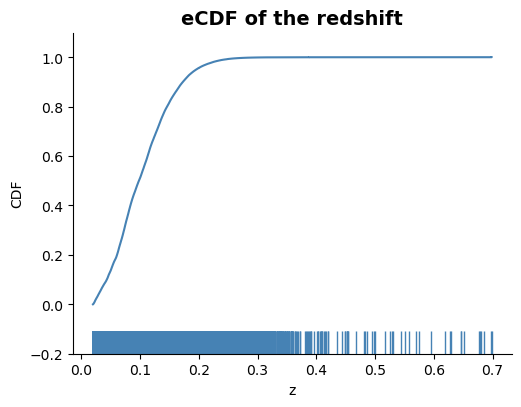

In [23]:
# Plot eCDF with the seaborn function 'displot', using kind 'ecdf'. The advantage is that a rug plot can be added directly.

sns.displot(data=df_full, x='Z', kind='ecdf', rug=True,  rug_kws={'linewidth': 1, "height": 0.07}, 
            color='steelblue', height=4, aspect=1.3)

plt.xlabel('z')
plt.ylabel('CDF')
plt.title('eCDF of the redshift', fontweight="bold", size=14)
plt.ylim(-0.2, 1.1)

Text(0.5, 1.0, 'r-band magnitude-redshift plot (0.08 < z < 0.12)')

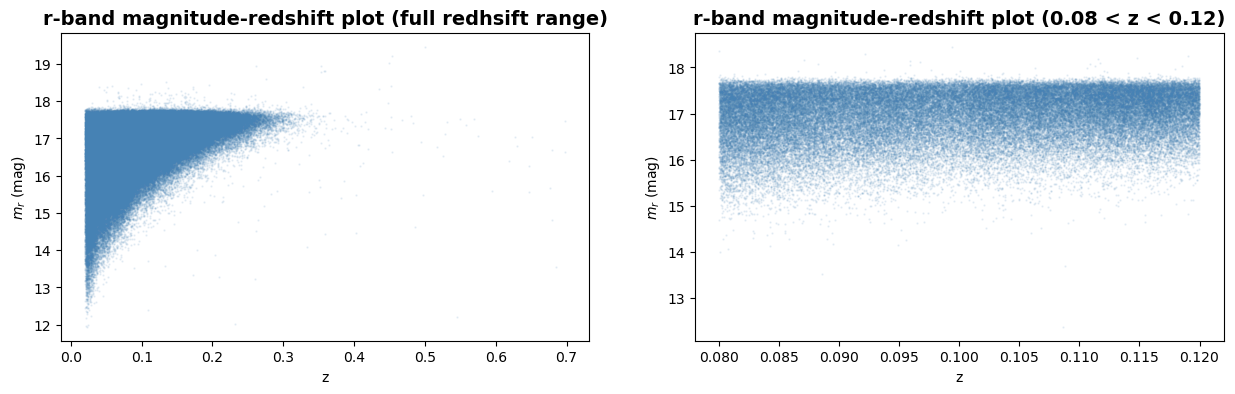

In [24]:
# scatter plot of r-band magnitude vs. redshift, once for the whole sample, once for the redshift range 0.08 < z < 0.12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))

ax1.scatter(df_full['Z'], df_full['phot_r'], s=0.5, alpha=0.1, color='steelblue')
ax1.set_xlabel('z')
ax1.set_ylabel('$m_{r}$ (mag)')
ax1.set_title('r-band magnitude-redshift plot (full redhsift range)', fontweight="bold", size=14)

ax2.scatter(df['Z'], df['phot_r'], s=0.5, alpha=0.1, color='steelblue')
ax2.set_xlabel('z')
ax2.set_ylabel('$m_{r}$ (mag)')
ax2.set_title('r-band magnitude-redshift plot (0.08 < z < 0.12)', fontweight="bold", size=14)


**Task 2**

In [9]:
# devide into red and blue galaxies by defining the condition for the colour (u-r <= 2.3: blue, u-r > 2.3: red) and
# storing the results in a new column 'population'

df['u_r'] = df['phot_u'] - df['phot_r']
df.loc[df['u_r'] <= 2.3, 'population'] = 'blue'
df.loc[df['u_r'] > 2.3, 'population'] = 'red'

print(df)

                RA        DEC         Z     phot_u     phot_g     phot_r  \
0       130.089951  52.178097  0.097629  19.854843  18.159964  17.345013   
7       130.080073  53.235523  0.118736  19.464210  18.210379  17.555952   
13      130.663027  50.071896  0.095350  20.303741  18.293287  17.320787   
18      131.179422  50.381649  0.117368  19.931213  18.112759  17.150190   
20      131.253821  50.354109  0.118596  19.746584  17.791237  16.751982   
...            ...        ...       ...        ...        ...        ...   
319936  149.619462  46.442470  0.102420  19.849287  18.035412  17.121490   
319941  149.744447  46.309440  0.114387  20.416435  18.376987  17.261572   
319943  149.536604  46.474948  0.102360  18.040950  16.418087  15.617054   
319950  149.777636  47.148649  0.105009  19.260720  17.999435  17.265516   
319955  149.937963  46.482358  0.102099  19.087252  17.185118  16.237055   

           phot_i     phot_z       u_r population  
0       16.930433  16.620535  2.509

Text(0.5, 1.0, 'Colour-magnitude diagram')

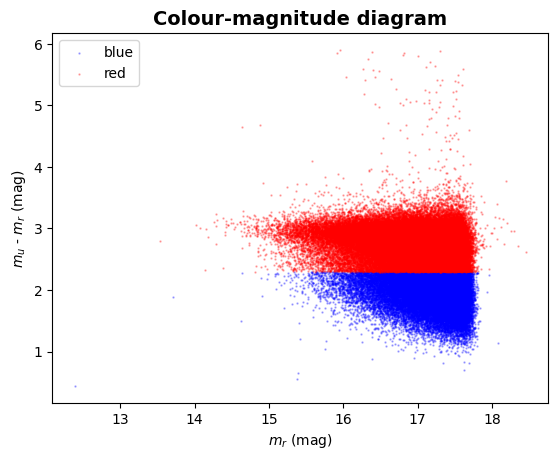

In [25]:
# plot colour-magnitude diagram and mark the red and blue galaxies by grouping over the column 'population'

plt.plot(figsize=(10,4))

colors = {'red': 'red', 'blue': 'blue'}

for name, group in df.groupby('population'):
    plt.scatter(group['phot_r'], group['u_r'], c=colors[name], label=name, s=0.5, alpha=0.3)

plt.xlabel('$m_{r}$ (mag)')
plt.ylabel('$m_{u}$ - $m_{r}$ (mag)')
plt.legend()
plt.title('Colour-magnitude diagram', fontweight="bold", size=14)


**Task 3**

In [12]:
# create subsamples of red and blue galaxies

df_red = df[df['population'] == 'red']
df_blue = df[df['population'] == 'blue']


In [13]:
# mean and std of the red subsample

r_mean_red = df_red['phot_r'].mean()
r_std_red = df_red['phot_r'].std()
print(r_mean_red, r_std_red)

# mean and std of the blue subsample

r_mean_blue = df_blue['phot_r'].mean()
r_std_blue = df_blue['phot_r'].std()
print(r_mean_blue, r_std_blue)


16.884902132896997 0.5532340973154652
17.148581973026662 0.431767649572343


In [14]:
# bootstrapping 95% confidence interval for mean (red galaxies)

data_red = df_red['phot_r'].dropna().to_numpy()

res_red = bootstrap((data_red,), np.mean, confidence_level=0.95,
                n_resamples=9999, method='basic')


In [15]:
# bootstrapping 95% confidence interval for mean (blue galaxies)

data_blue = df_blue['phot_r'].dropna().to_numpy()

res_blue = bootstrap((data_blue,), np.mean, confidence_level=0.95,
                n_resamples=9999, method='basic')

In [16]:
print(res_red)
print(res_blue)

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(16.880516744704984), high=np.float64(16.88925160234561)), bootstrap_distribution=array([16.88582235, 16.88259268, 16.88101492, ..., 16.88461791,
       16.88749921, 16.88383086]), standard_error=np.float64(0.0022253846062703854))
BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(17.14382784165682), high=np.float64(17.153484049865384)), bootstrap_distribution=array([17.14724523, 17.15064584, 17.15021266, ..., 17.14661761,
       17.14694991, 17.15194876]), standard_error=np.float64(0.0024788406570164976))


In [29]:
# analytic confidence interval for mean (red): 

n_red = len(data_red)
ci_red = stats.t.interval(0.95, df=n_red-1, loc=r_mean_red, scale=r_std_red/np.sqrt(n_red))
print(ci_red)

# analytic confidence interval for mean (blue): 

n_blue = len(data_blue)
ci_blue = stats.t.interval(0.95, df=n_blue-1, loc=r_mean_blue, scale=r_std_blue/np.sqrt(n_blue))
print(ci_blue)

(np.float64(16.880499334366263), np.float64(16.88930493142773))
(np.float64(17.14373267340006), np.float64(17.153431272653265))


**Task 4**

Text(0, 0.5, 'DEC')

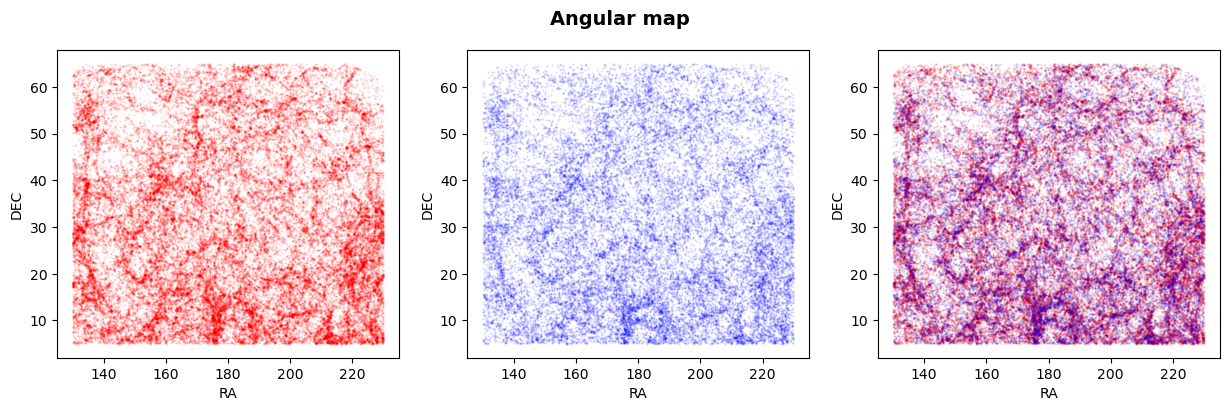

In [26]:
# plot RA vs DEC

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Angular map', fontweight="bold", size=14)

ax1.scatter(df_red['RA'], df_red['DEC'], s=0.5, alpha=0.1, color='red')
ax2.scatter(df_blue['RA'], df_blue['DEC'], s=0.5, alpha=0.1, color='blue')
ax3.scatter(df_red['RA'], df_red['DEC'], s=0.5, alpha=0.1, color='red')
ax3.scatter(df_blue['RA'], df_blue['DEC'], s=0.5, alpha=0.1, color='blue')


ax1.set_xlabel('RA')
ax1.set_ylabel('DEC')

ax2.set_xlabel('RA')
ax2.set_ylabel('DEC')

ax3.set_xlabel('RA')
ax3.set_ylabel('DEC')

Text(0, 0.5, 'z')

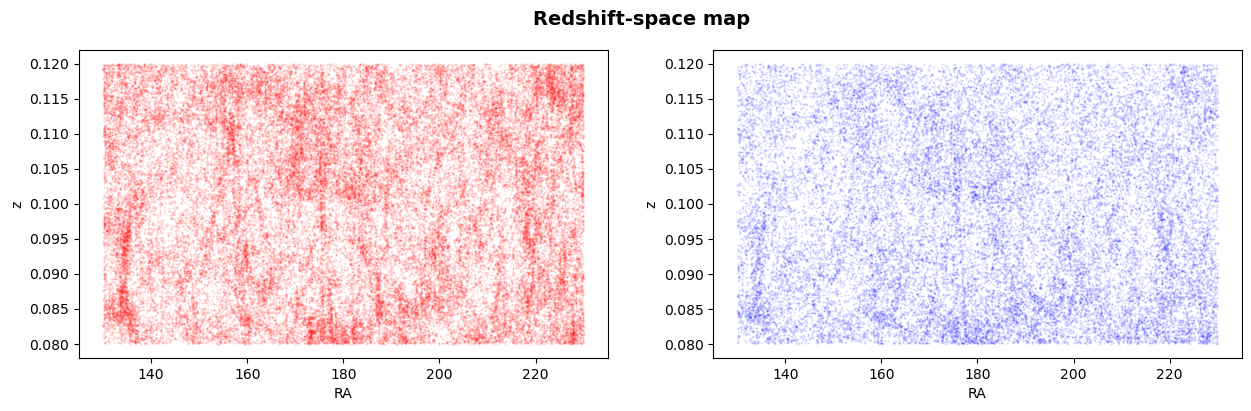

In [27]:
# plot RA vs redshift

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))
fig.suptitle('Redshift-space map', fontweight="bold", size=14)

ax1.scatter(df_red['RA'], df_red['Z'], s=0.5, alpha=0.1, color='red')
ax2.scatter(df_blue['RA'], df_blue['Z'], s=0.5, alpha=0.1, color='blue')

ax1.set_xlabel('RA')
ax1.set_ylabel('z')

ax2.set_xlabel('RA')
ax2.set_ylabel('z')
